# Projekt 2: Syntezator Ekspozycji i Rekonstrukcja HDR

## 1. Wstęp i Architektura
Celem projektu było stworzenie potoku przetwarzania, który z pojedynczego obrazu o standardowym zakresie dynamiki (LDR, 0 EV) generuje dwie dodatkowe ekspozycje: niedoświetloną (-2.7 EV) oraz prześwietloną (+2.7 EV). Obrazy te posłużyły do rekonstrukcji obrazu HDR przy użyciu algorytmu Debeveca.

Jako "syntezator ekspozycji" wykorzystano architekturę opartą na sieci **U-Net** z dwiema niezależnymi warstwami wyjściowymi (jedna dla obrazu niedoświetlonego, druga dla prześwietlonego) z aktywacją Sigmoid. Do nauki wykorzystano funkcję straty L1 Loss oraz optymalizator Adam.

## 2. Trening Modelu
Poniższa komórka importuje i uruchamia proces uczenia z pliku `main.py`. Zbiór danych został oczyszczony z uszkodzonych plików (brak metadanych), a algorytm automatycznie dobiera odpowiednie pary zdjęć na podstawie wartości *ExposureBiasValue* oraz czasu naświetlania. Zbiór testowy (C40-C46) został całkowicie odseparowany.

In [1]:
import sys
import os

path_to_classes = os.path.abspath('../classes')

if path_to_classes not in sys.path:
    sys.path.append(path_to_classes)

In [ ]:
from main import train

train()

## 3. Ewaluacja i Złożenie HDR
Proces testowy jest przeprowadzany na scenach C40-C46. Skrypt wczytuje wytrenowane wagi, generuje nowe ekspozycje, a następnie składa je w obraz HDR algorytmem Debeveca (z użyciem OpenCV), obliczając metryki jakości.

In [2]:
from evaluate import evaluate

evaluate()

d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\.venv\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warni

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth
Rozpoczynam ewaluację na scenach C40-C46...

Przetwarzam scenę: C40
Ścieżki: 
  Underexposed: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C40\DSC03940.JPG
  Input: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C40\DSC03936.JPG
  Overexposed: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C40\DSC03944.JPG
  Original HDR: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/HDR\C40_HDR.hdr


d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.


Przetwarzam scenę: C41
Ścieżki: 
  Underexposed: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C41\DSC03967.JPG
  Input: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C41\DSC03963.JPG
  Overexposed: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C41\DSC03971.JPG
  Original HDR: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/HDR\C41_HDR.hdr

Przetwarzam scenę: C42
Błąd podczas odczytywania metadanych z d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C42\DSC03972.JPG_crop.jpg: Missing metadata for image d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\2\classes\../../dataset/HDREye/images/Bracketed_images\C42\DSC03972.JPG_crop.jpg
Błąd podczas odczytywania metadanych z d:\studia\St

## 4. Wyniki Liczbowe
Wyniki dla wygenerowanych obrazów (PSNR, LPIPS) oraz zakresu dynamicznego zrekonstruowanych plików HDR.

In [3]:
import pandas as pd
from IPython.display import display
from constants import OUTPUT_DIR_PATH

try:
    df_metrics = pd.read_csv(f"{OUTPUT_DIR_PATH}/output.csv")
    
    print("Tabela 1: Metryki PSNR i LPIPS (Średnie dla C40-C46)")
    display(df_metrics)
except FileNotFoundError:
    print("Brak plików CSV. Upewnij się, że komórka ewaluacyjna wykonała się poprawnie.")

Tabela 1: Metryki PSNR i LPIPS (Średnie dla C40-C46)


,Scene,Dynamic Range Original,Dynamic Range New,PSNR Underexposed,PSNR Overexposed
0,C40,20.267975,12.167160,11.941838,12.252621
1,C41,17.996151,14.347689,9.600898,13.941069
2,C43,24.301859,16.835232,10.668562,10.953232


## 5. Wizualizacja Wyników
Wizualne zestawienie wygenerowanych ekspozycji (LDR) oraz porównanie zrekonstruowanego obrazu HDR z oryginalnym referencyjnym HDR po zastosowaniu mapowania tonalnego Reinharda.

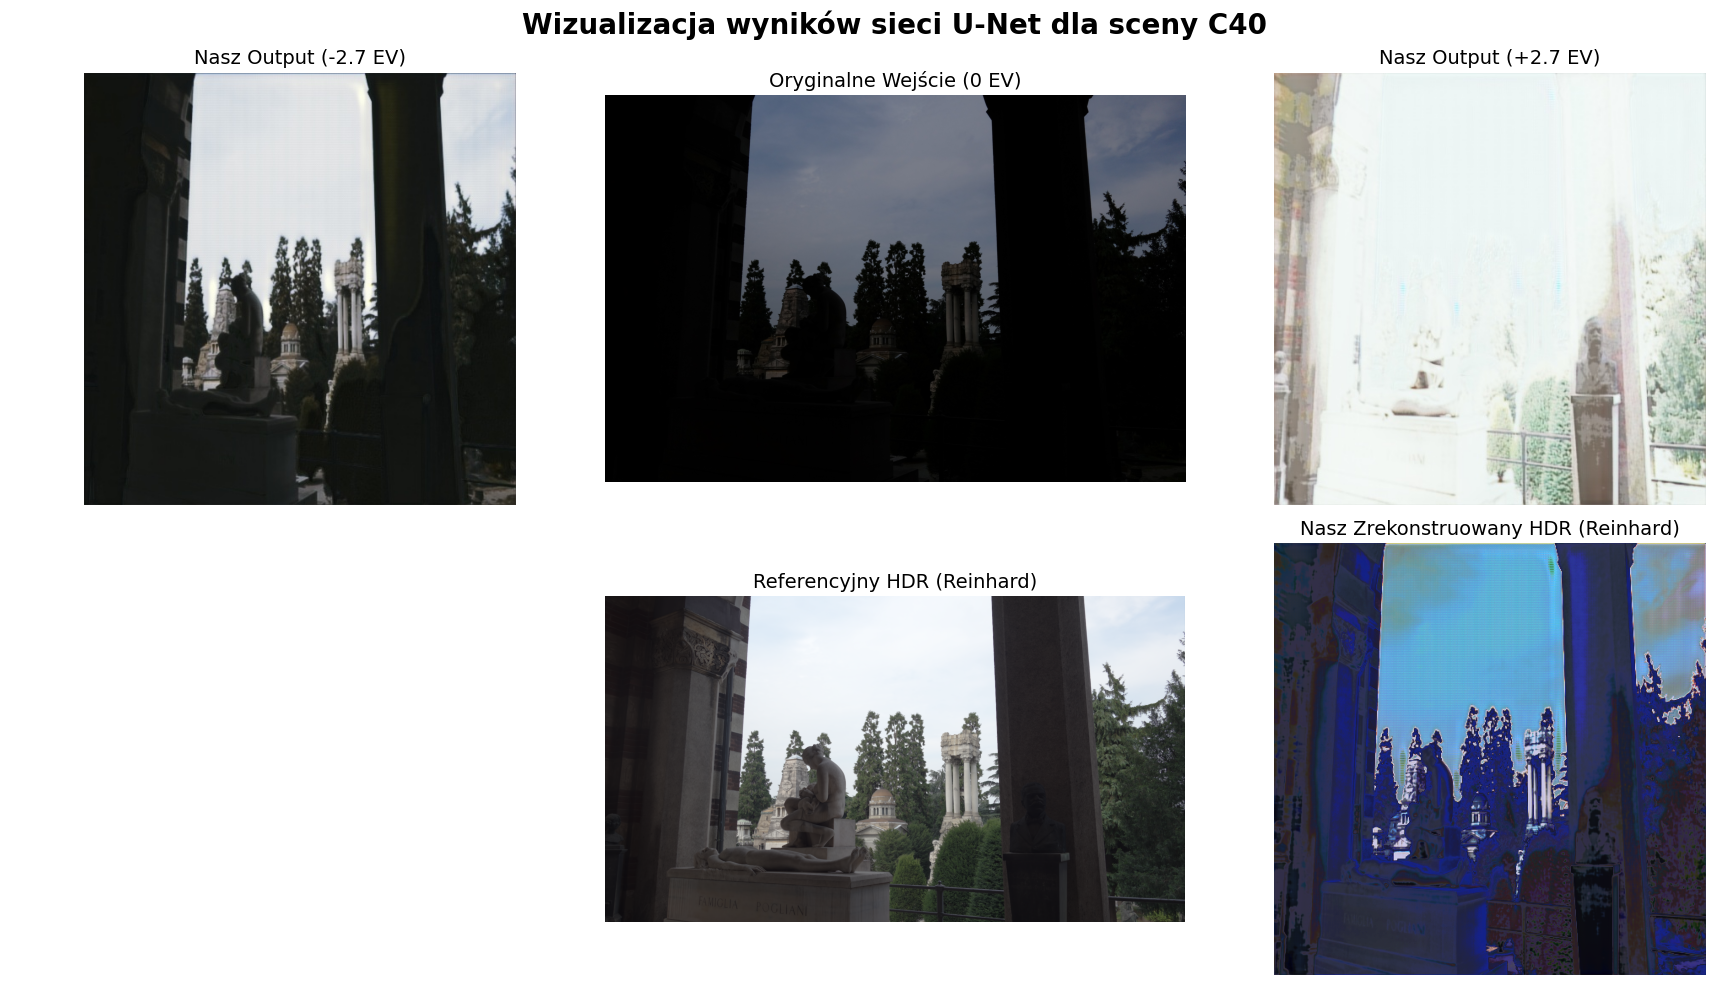

In [4]:
import matplotlib.pyplot as plt
import cv2
import os
from utils import read_hdr, tone_map_reinhard
from constants import DATASET_ROOT, HDR_ORIGINAL_ROOT, OUTPUT_DIR_PATH

SCENE_TO_VISUALIZE = "C40"

try:
    ldr_paths = sorted(os.listdir(os.path.join(DATASET_ROOT, SCENE_TO_VISUALIZE)))
    ldr_paths = [f for f in ldr_paths if f.lower().endswith('.jpg')]
    img_mid = cv2.cvtColor(cv2.imread(os.path.join(DATASET_ROOT, SCENE_TO_VISUALIZE, ldr_paths[len(ldr_paths)//2])), cv2.COLOR_BGR2RGB)

    scene_output_dir = os.path.join(OUTPUT_DIR_PATH, SCENE_TO_VISUALIZE)
    img_under_gen = cv2.cvtColor(cv2.imread(os.path.join(scene_output_dir, "gen_under.jpg")), cv2.COLOR_BGR2RGB)
    img_over_gen = cv2.cvtColor(cv2.imread(os.path.join(scene_output_dir, "gen_over.jpg")), cv2.COLOR_BGR2RGB)

    orig_hdr_path = os.path.join(HDR_ORIGINAL_ROOT, f"{SCENE_TO_VISUALIZE}_HDR.hdr")
    if not os.path.exists(orig_hdr_path):
        orig_hdr_path = os.path.join(HDR_ORIGINAL_ROOT, f"{SCENE_TO_VISUALIZE}.hdr")
        
    orig_hdr = read_hdr(orig_hdr_path)
    orig_hdr_tm = tone_map_reinhard(orig_hdr)

    gen_hdr_path = os.path.join(scene_output_dir, "gen_hdr.hdr")
    gen_hdr = read_hdr(gen_hdr_path)
    gen_hdr_tm = tone_map_reinhard(gen_hdr)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Wizualizacja wyników sieci U-Net dla sceny {SCENE_TO_VISUALIZE}", fontsize=20, fontweight='bold')

    axes[0, 0].imshow(img_under_gen)
    axes[0, 0].set_title("Nasz Output (-2.7 EV)", fontsize=14); axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_mid)
    axes[0, 1].set_title("Oryginalne Wejście (0 EV)", fontsize=14); axes[0, 1].axis('off')
    
    axes[0, 2].imshow(img_over_gen)
    axes[0, 2].set_title("Nasz Output (+2.7 EV)", fontsize=14); axes[0, 2].axis('off')

    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(orig_hdr_tm)
    axes[1, 1].set_title("Referencyjny HDR (Reinhard)", fontsize=14); axes[1, 1].axis('off')
    
    axes[1, 2].imshow(gen_hdr_tm)
    axes[1, 2].set_title("Nasz Zrekonstruowany HDR (Reinhard)", fontsize=14); axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Błąd wizualizacji: {e}")